In [1]:
import importlib
import sys

# for math operations
import numpy as np

# for plotting
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# for accelerated computing
import jax.numpy as jnp

In [2]:
import dubins_model
importlib.reload(dubins_model)
from dubins_model import Dubins3D

dubins = Dubins3D()

100%|##########|  2.8000/2.799999952316284 [00:00<00:00,  8.84sim_s/s]


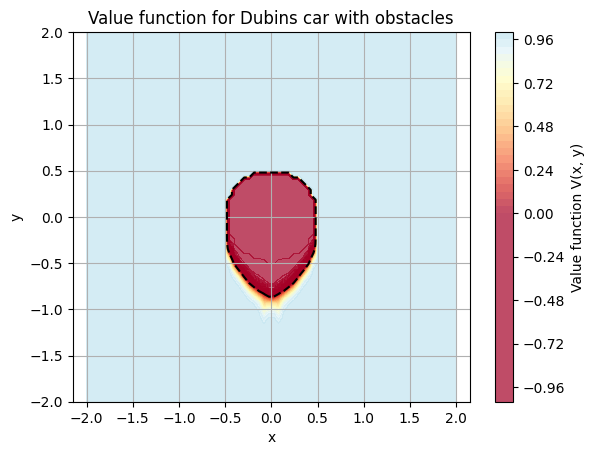

In [68]:
sys.path.append('./value_functions')
# import hj_value_function
# importlib.reload(hj_value_function)
from hj_value_function import HJValueFunction
from matplotlib import colors

grid_nx = grid_ny = 76
grid_ntheta = 51

value_func = HJValueFunction(dubins, 
                             grid_min=np.array([-2.0, -2.0, 0]),
                             grid_max=np.array([2.0, 2.0, 2 * np.pi]),
                             num_cells=np.array([grid_nx, grid_ny, grid_ntheta]))

# Define failure set
x_c, y_c, radius = 0.0, -1.2, 0.5
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius

# if obstacle1 > 0, failure_lx = 1, else -1
failure_lx = jnp.where(obstacle1 > 0, 1.0, -1.0)
# failure_lx = obstacle1

value_func.compute_V(failure_lx)

# Extract x and y grid for contour plotting
x = value_func.grid.states[..., 0][:, 0, 0]
y = value_func.grid.states[..., 1][0, :, 0]


# also plot the zero level set
plt.contour(x, y, value_func.val_grid[:, :, 0], levels=[0], colors='black', linewidths=1.5, linestyles='dashed')
plt.contourf(x, y, value_func.val_grid[:, :, 0], levels=50, cmap='RdYlBu', alpha=0.7)
plt.colorbar(label='Value function V(x, y)')
plt.axis('equal')
plt.ylim(-2, 2)
plt.grid()
plt.clim(0, 1.5)  # Adjust color limits for better visibility
plt.title('Value function for Dubins car with obstacles')
plt.xlabel('x')
plt.ylabel('y')
plt.show()



In [ ]:
import torch

x_vals = np.linspace(-2, 2, grid_nx)
y_vals = np.linspace(-2, 2, grid_ny)
theta_vals = np.linspace(0, 2*np.pi, grid_ntheta)
grid_points = np.array(np.meshgrid(x_vals, y_vals, theta_vals, indexing='ij')).reshape(3, -1).T

def reward_fn(states):
    d = np.linalg.norm(states[:, :2], axis=1)
    return np.where(d > radius, -1.0, 0.0)

def dynamics_step(state, action, dt=0.1):
    state_tensor = torch.tensor(state[None], dtype=torch.float32)
    action_tensor = torch.tensor(action[None], dtype=torch.float32)
    next_state = dubins.discrete_rk4(state_tensor, action_tensor, dt)
    return next_state[0].detach().numpy()

from scipy.interpolate import RegularGridInterpolator

def get_value_function_interpolator(V):
    return RegularGridInterpolator((x_vals, y_vals, theta_vals), V.reshape(grid_nx, grid_ny, grid_ntheta), bounds_error=False, fill_value=0.0)

V = np.zeros(len(grid_points))
gamma = 0.99
dt = 0.1
actions = np.linspace(-1.0, 1.0, 10).reshape(-1, 1)  # 10 actions from -1 to 1, reshaped to
num_states = grid_points.shape[0]
num_actions = actions.shape[0]

states = torch.tensor(grid_points, dtype=torch.float32)  # (S, 3)
rewards = reward_fn(grid_points)  # (S,)

goal_mask = np.linalg.norm(grid_points[:, :2], axis=1) <= radius  # (N,) boolean


for iteration in range(500):
    print(f"Iteration {iteration}")

    # Expand state-action pairs
    states_batch = states.repeat_interleave(num_actions, dim=0)  # (S*A, 3)
    actions_batch = torch.tensor(np.tile(actions, (num_states, 1)), dtype=torch.float32)  # (S*A, 1)

    # Batch dynamics
    next_states = dubins.discrete_rk4(states_batch, actions_batch, dt).detach().numpy()  # (S*A, 3)
    next_states[:, 0] = np.clip(next_states[:, 0], x_vals[0], x_vals[-1])
    next_states[:, 1] = np.clip(next_states[:, 1], y_vals[0], y_vals[-1])
    next_states[:, 2] = np.mod(next_states[:, 2], 2 * np.pi)

    # Interpolate value
    interp = get_value_function_interpolator(V)
    v_next = interp(next_states).reshape(num_states, num_actions)  # (S, A)

    # Bellman update
    total_return = rewards[:, None] + gamma * v_next  # (S, A)
    V_new = (np.max(total_return, axis=1))  # (S,)
    V_new[goal_mask] = 0.0

    print(f"Max value change: {np.max(np.abs(V_new - V))}")
    if np.max(np.abs(V_new - V)) < 1e-4:
        break
    V = V_new


Iteration 0
Max value change: 1.0
Iteration 1
Max value change: 0.99
Iteration 2
Max value change: 0.9801000000000002
Iteration 3
Max value change: 0.9702990000000002
Iteration 4
Max value change: 0.9605960100000015
Iteration 5
Max value change: 0.9509900499000015
Iteration 6
Max value change: 0.9414801494010021
Iteration 7
Max value change: 0.9320653479069918
Iteration 8
Max value change: 0.922744694427923
Iteration 9
Max value change: 0.9135172474836448
Iteration 10
Max value change: 0.9043820750088081
Iteration 11
Max value change: 0.8953382542587196
Iteration 12
Max value change: 0.8863848717161336
Iteration 13
Max value change: 0.8775210229989714
Iteration 14
Max value change: 0.8687458127689833
Iteration 15
Max value change: 0.8600583546412945
Iteration 16
Max value change: 0.8514577710948803
Iteration 17
Max value change: 0.8429431933839346
Iteration 18
Max value change: 0.8345137614500935
Iteration 19
Max value change: 0.8261686238355956
Iteration 20
Max value change: 0.8179069

In [40]:
V_out = -V.reshape(grid_nx, grid_ny, grid_ntheta)

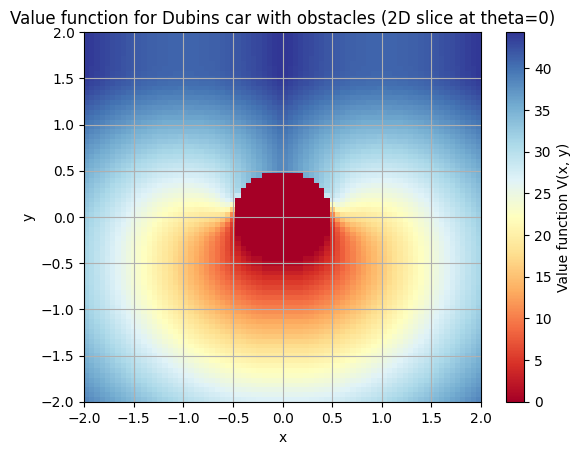

In [42]:
# plot a slice at theta = 0
V_2d = V_out.reshape(grid_nx, grid_ny, grid_ntheta)[:, :, 0]  # take the first slice at theta = 0
plt.imshow(V_2d, extent=(-2, 2, -2, 2), origin='lower', cmap='RdYlBu', aspect='auto')
plt.colorbar(label='Value function V(x, y)')
plt.title('Value function for Dubins car with obstacles (2D slice at theta=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.show()

In [ ]:
x_vals = np.linspace(-2, 2, grid_nx)
y_vals = np.linspace(-2, 2, grid_ny)
theta_vals = np.linspace(0, 2*np.pi, grid_ntheta)
grid_points = np.array(np.meshgrid(x_vals, y_vals, theta_vals, indexing='ij')).reshape(3, -1).T

def reward_fn(states):
    d = np.linalg.norm(states[:, :2], axis=1)
    return np.where(d > radius, 0, 1)

def dynamics_step(state, action, dt=0.1):
    state_tensor = torch.tensor(state[None], dtype=torch.float32)
    action_tensor = torch.tensor(action[None], dtype=torch.float32)
    next_state = dubins.discrete_rk4(state_tensor, action_tensor, dt)
    return next_state[0].detach().numpy()

from scipy.interpolate import RegularGridInterpolator

def get_value_function_interpolator(V):
    return RegularGridInterpolator((x_vals, y_vals, theta_vals), V.reshape(grid_nx, grid_ny, grid_ntheta), bounds_error=False, fill_value=0.0)

V = np.zeros(len(grid_points))
gamma = 0.99
dt = 0.1
# actions = np.array([[-1.0], [0.0], [1.0]])
actions = np.linspace(-1.0, 1.0, 10).reshape(-1, 1)  # 10 actions from -1 to 1, reshaped to
num_states = grid_points.shape[0]
num_actions = actions.shape[0]

states = torch.tensor(grid_points, dtype=torch.float32)  # (S, 3)
rewards = reward_fn(grid_points)  # (S,)

goal_mask = np.linalg.norm(grid_points[:, :2], axis=1) >= radius  # (N,) boolean


for iteration in range(500):
    print(f"Iteration {iteration}")

    # Expand state-action pairs
    states_batch = states.repeat_interleave(num_actions, dim=0)  # (S*A, 3)
    actions_batch = torch.tensor(np.tile(actions, (num_states, 1)), dtype=torch.float32)  # (S*A, 1)

    # Batch dynamics
    next_states = dubins.discrete_rk4(states_batch, actions_batch, dt).detach().numpy()  # (S*A, 3)
    next_states[:, 0] = np.clip(next_states[:, 0], x_vals[0], x_vals[-1])
    next_states[:, 1] = np.clip(next_states[:, 1], y_vals[0], y_vals[-1])
    next_states[:, 2] = np.mod(next_states[:, 2], 2 * np.pi)

    # Interpolate value
    interp = get_value_function_interpolator(V)
    v_next = interp(next_states).reshape(num_states, num_actions)  # (S, A)

    # Bellman update
    total_return = rewards[:, None] + gamma * v_next  # (S, A)
    V_new = (np.max(total_return, axis=1))  # (S,)
    V_new[goal_mask] = 0.0

    print(f"Max value change: {np.max(np.abs(V_new - V))}")
    if np.max(np.abs(V_new - V)) < 1e-4:
        break
    V = V_new

Iteration 0
Max value change: 1.0
Iteration 1
Max value change: 0.9900000000000004
Iteration 2
Max value change: 0.9801000000000011
Iteration 3
Max value change: 0.9702990000000016
Iteration 4
Max value change: 0.9605960100000024
Iteration 5
Max value change: 0.9509900499000032
Iteration 6
Max value change: 0.9414801494010039
Iteration 7
Max value change: 0.9320653479069936
Iteration 8
Max value change: 0.9227446944279256
Iteration 9
Max value change: 0.9135172474836484
Iteration 10
Max value change: 0.9043820750088116
Iteration 11
Max value change: 0.8953382542587214
Iteration 12
Max value change: 0.8863848717161353
Iteration 13
Max value change: 0.8775210229989749
Iteration 14
Max value change: 0.8687458127689833
Iteration 15
Max value change: 0.8600583546412928
Iteration 16
Max value change: 0.8514577710948803
Iteration 17
Max value change: 0.8429431933837304
Iteration 18
Max value change: 0.824264611754078
Iteration 19
Max value change: 0.7979229522773466
Iteration 20
Max value cha

In [45]:
V_in = -V.reshape(grid_nx, grid_ny, grid_ntheta)

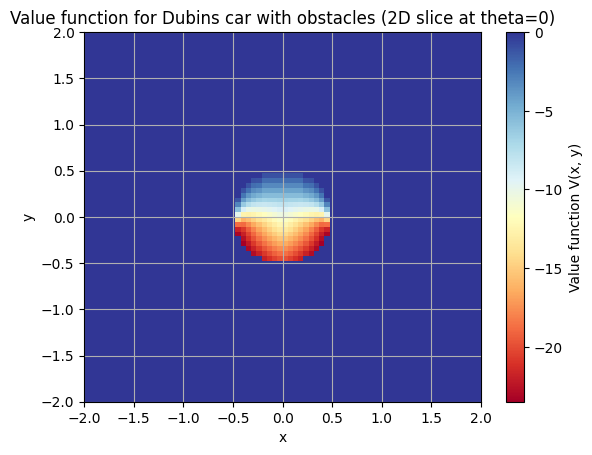

In [47]:
# plot a slice at theta = 0
V_2d = V_in.reshape(grid_nx, grid_ny, grid_ntheta)[:, :, 0]  # take the first slice at theta = 0
plt.imshow(V_2d, extent=(-2, 2, -2, 2), origin='lower', cmap='RdYlBu', aspect='auto')
plt.colorbar(label='Value function V(x, y)')
plt.title('Value function for Dubins car with obstacles (2D slice at theta=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.show()

In [48]:
V_tot = V_out + V_in

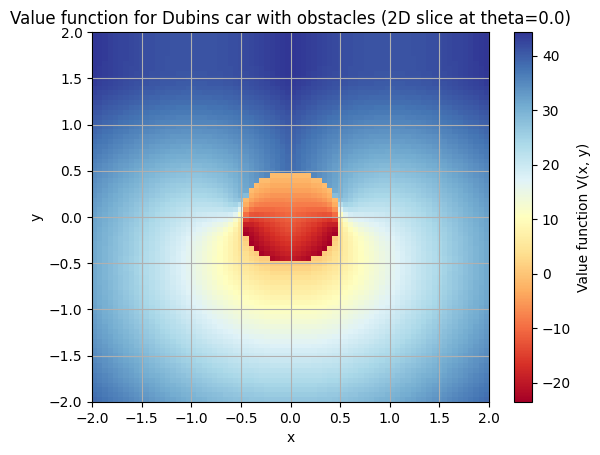

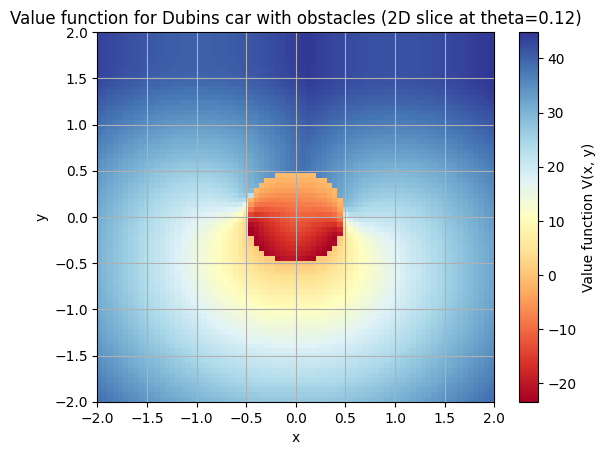

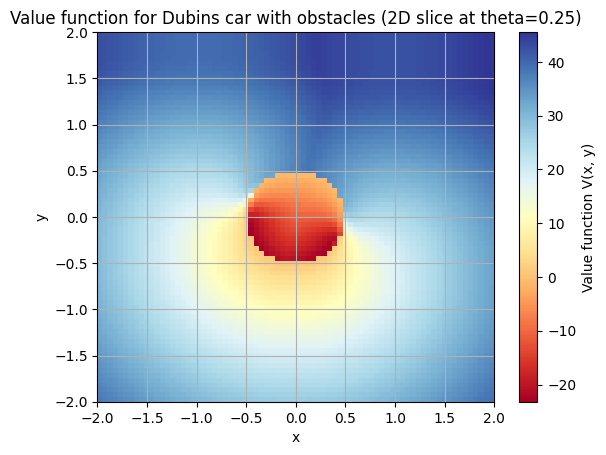

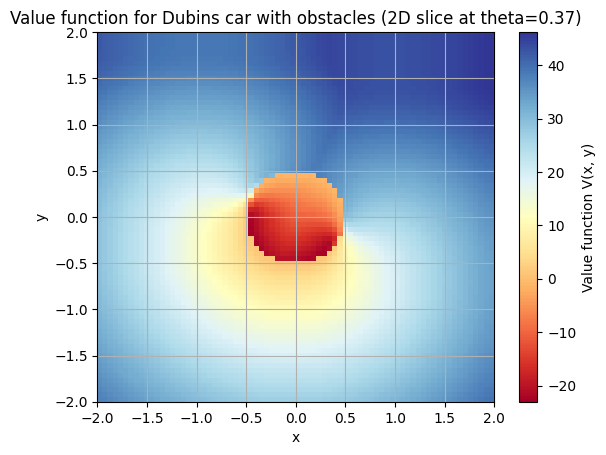

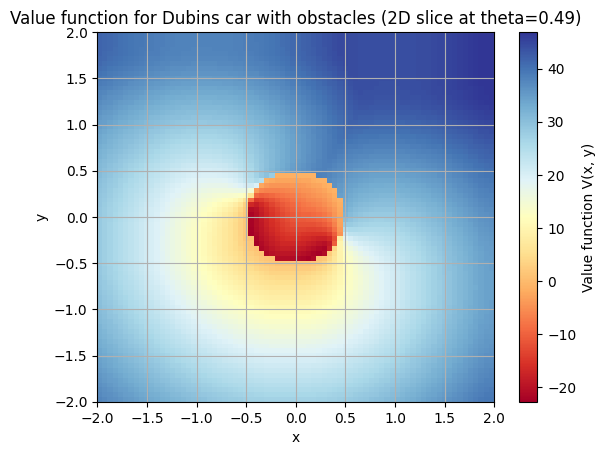

In [55]:
for i in range(5):
    V_2d = (V_tot)[:, :, i]  # take the i-th slice at theta = i
    plt.imshow(V_2d, extent=(-2, 2, -2, 2), origin='lower', cmap='RdYlBu', aspect='auto')
    plt.colorbar(label='Value function V(x, y)')
    plt.title(f'Value function for Dubins car with obstacles (2D slice at theta={np.round(2*np.pi * i / grid_ntheta, 2)})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.grid()
    plt.show()

In [66]:
value_func = HJValueFunction(dubins, 
                             grid_min=np.array([-2.0, -2.0, 0]),
                             grid_max=np.array([2.0, 2.0, 2 * np.pi]),
                             num_cells=np.array([grid_nx, grid_ny, grid_ntheta]))

# Define failure set
failure_lx = V_tot
# failure_lx = V_out
value_func.compute_V(failure_lx)

# Extract x and y grid for contour plotting
x = value_func.grid.states[..., 0][:, 0, 0]
y = value_func.grid.states[..., 1][0, :, 0]

100%|##########|  2.8000/2.799999952316284 [00:00<00:00, 35.74sim_s/s]


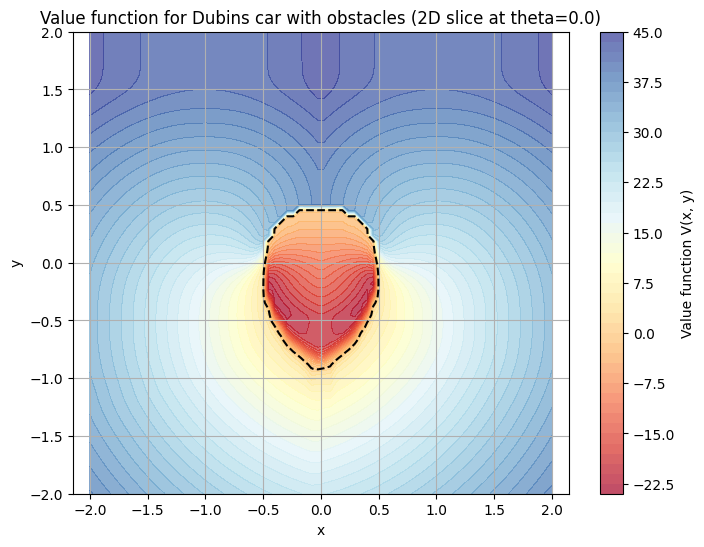

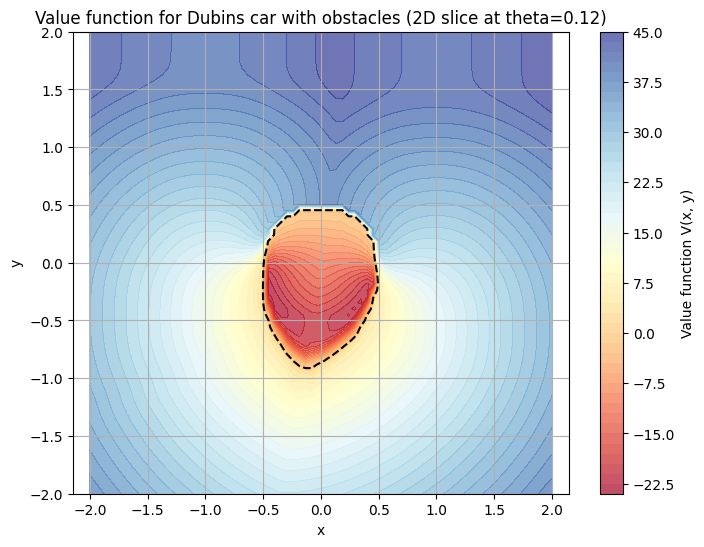

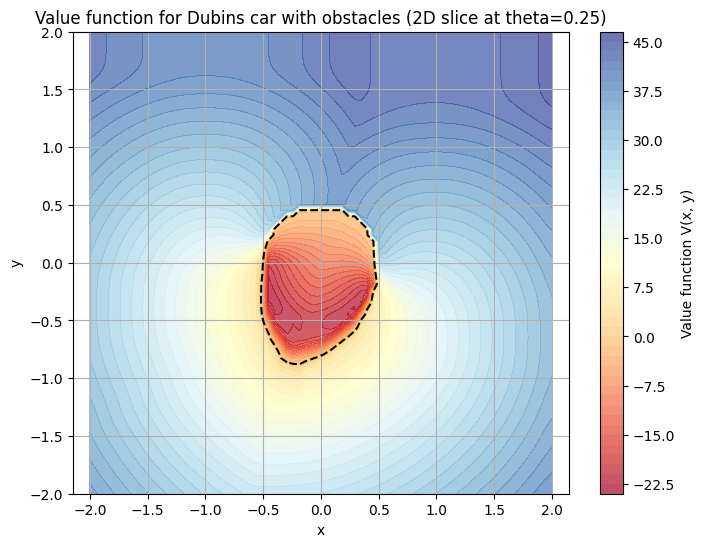

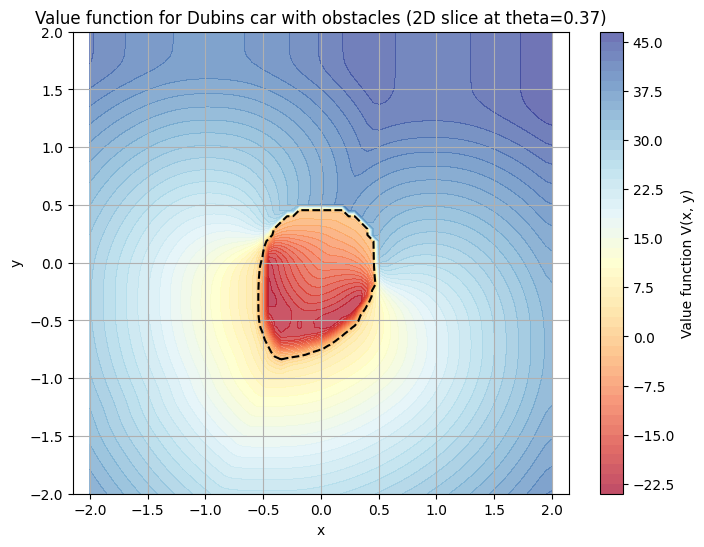

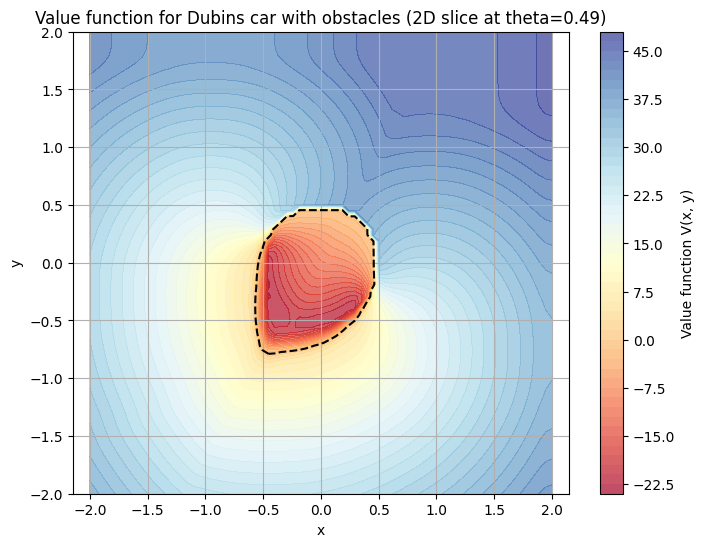

In [67]:
for i in range(5):
    plt.figure(figsize=(8, 6))
    plt.contour(x, y, value_func.val_grid[:, :, i], levels=[0], colors='black', linewidths=1.5, linestyles='dashed')
    plt.contourf(x, y, value_func.val_grid[:, :, i], levels=50, cmap='RdYlBu', alpha=0.7)

    plt.colorbar(label='Value function V(x, y)')
    plt.axis('equal')
    plt.ylim(-2, 2)
    plt.grid()
    plt.title(f'Value function for Dubins car with obstacles (2D slice at theta={np.round(2*np.pi * i / grid_ntheta, 2)})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()